In [1]:
import bigfile
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D
from nbodykit.lab import BigFileCatalog
from scipy.spatial import distance

# Import class to analyze MP_Gadget run snapshots
from dm_snapshot_analysis import SnapshotData

In [6]:
# Snapshot imports to obtain DM particle attributes
snapshot = '/home/aschann/MP-Gadget-Original-Backup/DM_Halos_March10/output/PART_006'
s1 = '/home/aschann/MP-Gadget-Original-Backup/DM_Halos_March10/output/PART_001'

# Import class to obtain data from snapshot 
# (currently only has GroupID and positions functionality)
sdata = SnapshotData(snapshot)
s1data = SnapshotData(s1)

In [7]:
# Import data manually/separately to look at 'new' parameters
data = BigFileCatalog(snapshot, dataset='1/', header='Header')

# Get data without "lazy" array retrieval (yet)
pos = data['Position'].compute() / 1000
group_ids = data['GroupID'].compute()

In [8]:
np.shape(pos)

(2097152, 3)

In [5]:
np.shape(pos)

(2097152, 3)

In [4]:
# Let's look at Velocity next
!ls output/PART_006/1/

GroupID  ID  Mass  Position  Potential	Velocity


In [31]:
p_id = data['ID'].compute()
p_id

array([2097146, 2064767,     251, ...,   16378,   16635,     122],
      dtype=uint64)

In [33]:
p1_id = data['ID'].compute()
p1_id

array([2097146, 2064767,     251, ...,   16378,   16635,     122],
      dtype=uint64)

In [5]:
vel = data['Velocity'].compute()

In [6]:
vel

array([[-196.73647 ,  203.26062 , 1024.8463  ],
       [ -19.191334, -292.95596 ,  194.46721 ],
       [-429.29614 , -213.30347 ,  772.6315  ],
       ...,
       [-146.04608 ,  156.31967 ,  938.0456  ],
       [-192.57442 ,  -17.066397,  680.50635 ],
       [-146.27608 ,  157.61673 ,  881.38416 ]], dtype=float32)

In [7]:
np.shape(vel)

(2097152, 3)

In [8]:
# Check sum of all velocities ?????
np.sum(vel, axis=0)

array([-2975.6606,  -281.4519,  1299.7515], dtype=float32)

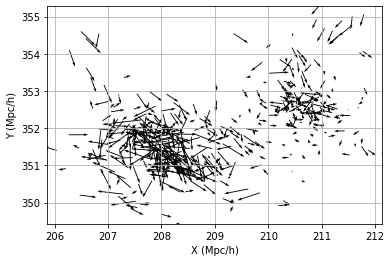

In [9]:
# Let's look at velocities of 2 halos near each other
target_group_ids = [46, 8]

# Filter particles by group IDs
#particle_dict = sdata.filter_particles_by_group(target_group_ids)

mask = np.isin(group_ids, target_group_ids)
t_pos = pos[mask]
t_vel = vel[mask]
t_group_ids = group_ids[mask]

# Plot these velocities -- currently having problems
x = t_pos[:,0]
y = t_pos[:,1]
z = t_pos[:,2]
u = t_vel[:,0]
v = t_vel[:,1]
w = t_vel[:,2]

fig, ax = plt.subplots()
    
ax.quiver(y,z,v,w, angles='xy', scale_units='xy', scale=5000)
ax.set_xlim([np.min(y), np.max(y)])
ax.set_ylim([np.min(z), np.max(z)]) 
        
plt.xlabel('X (Mpc/h)')
plt.ylabel('Y (Mpc/h)')
plt.grid(True)
plt.show()

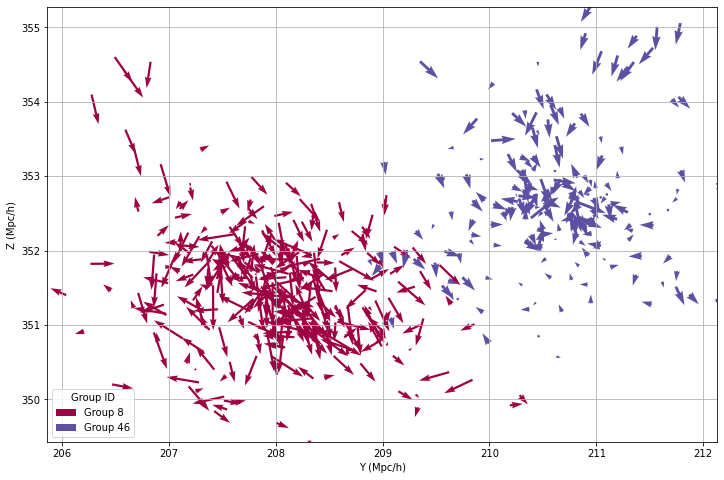

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Assume group_ids, pos, and vel are already defined and filtered to include only target groups
target_group_ids = [46, 8]
mask = np.isin(group_ids, target_group_ids)
t_pos = pos[mask]
t_vel = vel[mask]
t_group_ids = group_ids[mask]

# Unique group IDs and colormap
unique_groups = np.unique(t_group_ids)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_groups)))  # Using 'viridis' colormap

# Create a color dictionary for each group ID
color_dict = {uid: color for uid, color in zip(unique_groups, colors)}

# Setup plot
fig, ax = plt.subplots(figsize=(12,8))

# Plotting velocities with different colors for different groups
for group in unique_groups:
    group_mask = t_group_ids == group
    x, y, z = t_pos[group_mask, 0], t_pos[group_mask, 1], t_pos[group_mask, 2]
    u, v, w = t_vel[group_mask, 0], t_vel[group_mask, 1], t_vel[group_mask, 2]

    ax.quiver(y, z, v, w, color=color_dict[group], scale=50_000, label=f'Group {group}')
    
ax.set_xlim([np.min(t_pos[:,1]), np.max(t_pos[:,1])])
ax.set_ylim([np.min(t_pos[:,2]), np.max(t_pos[:,2])])
ax.set_xlabel('Y (Mpc/h)')
ax.set_ylabel('Z (Mpc/h)')
ax.legend(title='Group ID')
plt.grid(True)
plt.show()

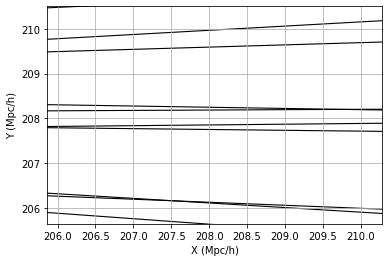

In [11]:
### X AND Y VECTOR PLOTS -- BAD

# Let's look at velocities of 2 halos near each other
target_group_ids = [8]

# Filter particles by group IDs
#particle_dict = sdata.filter_particles_by_group(target_group_ids)

mask = np.isin(group_ids, target_group_ids)
t_pos = pos[mask]
t_vel = vel[mask]
t_group_ids = group_ids[mask]

# Plot these velocities -- currently having problems
x = t_pos[:,0]
y = t_pos[:,1]
u = t_vel[:,0]
v = t_vel[:,1]
    
fig, ax = plt.subplots()
    
ax.quiver(x,y,u,v, angles='xy', scale_units='xy', scale=1)
ax.set_xlim([np.min(x), np.max(x)])
ax.set_xlim([np.min(y), np.max(y)]) 
        
plt.xlabel('X (Mpc/h)')
plt.ylabel('Y (Mpc/h)')
plt.grid(True)
plt.show()

### ANGULAR MOMENTUM EXAMINATIONS BELOW

In [12]:
# We should first check to see if mass is in fact the same, as it should be
mass = data['Mass'].compute()

mass

array([465.52756, 465.52756, 465.52756, ..., 465.52756, 465.52756,
       465.52756], dtype=float32)

In [13]:
mass[0]

465.52756

In [14]:
sdata.calculate_angular_momentum()

{1: array([  1188880.05760347,  31581359.97163409, -63487210.99754224]),
 2: array([39442898.02317505,  -705117.91129594, 12773524.2394364 ]),
 3: array([  1713437.1387882 ,   9378641.89096212, -12120264.95222479]),
 4: array([-21210769.49038185,  16791430.13761754,  51007542.21025653]),
 5: array([ 14706862.22166463, -28510009.64974353, -12868639.69630059]),
 6: array([-11316111.6745906 , -10458048.70318764,  14233852.14131704]),
 7: array([ 23018346.05853095,  -3018531.19055254, -28992489.94635987]),
 8: array([-17788897.73603774, -18069861.27552459, -45932979.85050049]),
 9: array([ 13676475.46166325,   6545701.10435796, -57109757.00234668]),
 10: array([-1.10105554e+07,  4.54555290e+08, -6.04311893e+08]),
 11: array([-19358886.79011772, -21324262.69412458,  -2093021.21523383]),
 12: array([15078074.23965458, 34314671.63684901, 18176240.79645865]),
 13: array([-11728750.58094868,  -2679246.8147932 ,  -3498438.30641814]),
 14: array([  6198987.11253556, -10962644.40310931,  -6147985.

In [15]:
# Try to use class method to get angular momentum of following groups: 46 and 8
L = sdata.calculate_angular_momentum((46,8))
L

{8: array([-17788897.73603774, -18069861.27552459, -45932979.85050049]),
 46: array([ 3764331.35489691, 21318204.33265286,  9309337.87426331])}

In [16]:
L46 = L[46]
L8 = L[8]

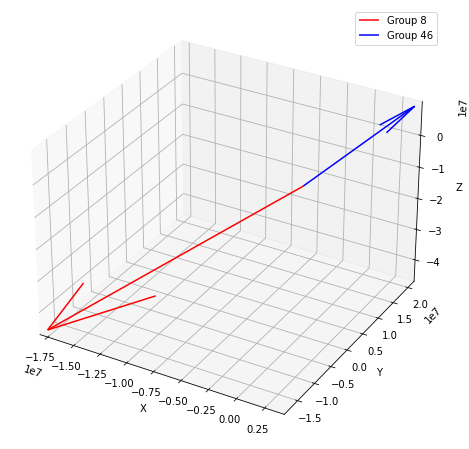

In [17]:
# Plot angular momenta
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')

origin = [0,0,0]

ax.quiver(*origin, *L8, color='r', label='Group 8')
ax.quiver(*origin, *L46, color='b', label='Group 46')

ax.set_xlim([min(L8[0], L46[0]), max(L8[0], L46[0])])
ax.set_ylim([min(L8[1], L46[1]), max(L8[1], L46[1])])
ax.set_zlim([min(L8[2], L46[2]), max(L8[2], L46[2])])

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.legend()
plt.show()

In [18]:
# Test mass of total box / all particles
mass.shape
m_tot = np.sum(mass)
np.format_float_scientific(np.sum(mass))

'9.762853e+08'

In [19]:
# Convert to proper unit (g): Unit Mass = 1.989 x 10e43
m_tot * 1.989e43

1.941831485568e+52

In [20]:
sdata.calculate_system_angular_momentum()

array([ 1.81960742e+11,  7.35845959e+10, -3.31845626e+11])

In [20]:
# Calculate all total angular momentum
L_tot = sdata.calculate_angular_momentum()
L_tot

{1: array([  1188880.05760347,  31581359.97163409, -63487210.99754224]),
 2: array([39442898.02317505,  -705117.91129594, 12773524.2394364 ]),
 3: array([  1713437.1387882 ,   9378641.89096212, -12120264.95222479]),
 4: array([-21210769.49038185,  16791430.13761754,  51007542.21025653]),
 5: array([ 14706862.22166463, -28510009.64974353, -12868639.69630059]),
 6: array([-11316111.6745906 , -10458048.70318764,  14233852.14131704]),
 7: array([ 23018346.05853095,  -3018531.19055254, -28992489.94635987]),
 8: array([-17788897.73603774, -18069861.27552459, -45932979.85050049]),
 9: array([ 13676475.46166325,   6545701.10435796, -57109757.00234668]),
 10: array([-1.10105554e+07,  4.54555290e+08, -6.04311893e+08]),
 11: array([-19358886.79011772, -21324262.69412458,  -2093021.21523383]),
 12: array([15078074.23965458, 34314671.63684901, 18176240.79645865]),
 13: array([-11728750.58094868,  -2679246.8147932 ,  -3498438.30641814]),
 14: array([  6198987.11253556, -10962644.40310931,  -6147985.

In [21]:
L_tot[4294967295]

array([ 1.77438119e+11,  4.91116669e+10, -2.09565580e+11])

In [22]:
L_total = np.array([0.,0.,0.])

for L in L_tot.values():
    L_total += L
    
print(L_total)

[ 1.78392137e+11  5.06347927e+10 -2.10397174e+11]


In [23]:
## ROUTINE: calculate total angular momentum 
# use center of mass as 'barycenter' to calculate L of each particle
def calculate_com(pos, masses):
    masses = masses[:,np.newaxis]
    total_mass = np.sum(masses)
    
    weighted_pos_sum = np.sum(masses * pos, axis=0)
    
    center_of_mass = weighted_pos_sum / total_mass
    
    return center_of_mass


def calculate_system_angular_momentum(pos, vel, masses, center_of_mass):
    relative_pos = pos - center_of_mass
    
    masses = masses[:, np.newaxis]
    
    L_individual = np.cross(relative_pos, masses*vel)
    
    L_total = np.sum(L_individual, axis=0)
    
    return L_total


com = calculate_com(pos, mass)
com

array([251.06249895, 247.76995616, 247.69104203])

In [24]:
# Total system's angular momentum
calculate_system_angular_momentum(pos, vel, mass, com)

array([ 1.81960742e+11,  7.35845959e+10, -3.31845626e+11])

In [25]:
# RMS of velocity and postion
def calculate_rms(values):
    """
    Calculates root mean square of provided array of values.
    
    Returns: float: the RMS value
    """
    rms = np.sqrt( np.mean( np.square(values) ) )
    return rms

# Calculate relative positons
relative_pos = pos - com

# Calculate radii from center of mass
radii = np.linalg.norm(relative_pos, axis=1)

# Calculate velocity magnitudes
vel_mag = np.linalg.norm(vel, axis=1)

# Calculate RMS values
rms_radius = calculate_rms(radii)
rms_vel = calculate_rms(vel_mag)

print(f"RMS radius: {rms_radius}")
print(f"RMS velocity: {rms_vel}")

RMS radius: 248.93999382216276
RMS velocity: 586.1904296875
